# 06d — Audit + experiments to beat majority voting (G=28)

Builds on **06c** (loads its cached G=28 artifacts). Two parts:
- **Audit**: mechanistic diagnostics of *why* the alignment-based barycenter does not beat the
  symbol-frequency baselines on this data.
- **Experiments**: honest attempts to beat `majority_voting` (transition/ordering features, re-selected
  hyperparameters, soft-mode DBA, length & mean-vs-mode ablations). Success = BH-significant paired
  Wilcoxon win over majority voting. **No p-hacking.**

**Session-2 fix (representation).** The previous version ran the entire audit at `L=64` — the
resample length that Session 1 showed *cripples* the alignment methods. This rewrite runs the audits
at a faithful interpolation length `AUDIT_L = 512` (the regime where the alignment methods have
recovered most of their discriminative power; Session-1 finding). The **definitive full-length
(L≈5162)** comparison lives in notebook **06** (hardened rTWE kernel): there the alignment exemplar
`k_medoid` *falls* to ~0.70 while the frequency histogram holds ~0.82 — so the audit's mechanistic
conclusion (the group signal is symbol frequency, not alignment) is what drives that full-length
plateau.

In [1]:
%load_ext autoreload
%autoreload 2
import os
os.environ.setdefault('NUMBA_THREADING_LAYER', 'workqueue')  # fork-safe rTWE under the nbconvert kernel
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
import smartflat
from joblib import load
from smartflat.utils.utils_io import get_data_root
from smartflat.utils.utils import upsample_sequence
from smartflat.constants import incomplete_clinical_administrations
from smartflat.features.symbolization.utils import fix_clinical_diagnosis
from smartflat.features.symbolic_barycenter import vocab
from smartflat.features.symbolic_barycenter import baselines as B
from smartflat.features.symbolic_barycenter.baselines import make_patient_control_labels
from smartflat.features.symbolic_barycenter.visualization import audit_scatter, audit_line_vs_lambda
from smartflat.engine.distances._rtwe import rtwe_pairwise_distance, rtwe_alignment_path
plt.rcParams['figure.dpi'] = 110

ANN, RND, CFG = 'samperochon', 8, 'SymbolicSourceInferenceGoldConfig'
AUDIT_L, NU, LMBDA, OFFSET = 512, 1e-4, 0.1, 0.3   # faithful audit length (was L=64)
OUT = os.path.join(get_data_root(), 'outputs', 'symbolic_barycenter', 'g28')
AUD = os.path.join(OUT, 'audit'); EXP = os.path.join(OUT, 'experiments')
os.makedirs(AUD, exist_ok=True); os.makedirs(EXP, exist_ok=True)

In [2]:
# --- load cached G=28 artifacts from 06c and rebuild the analysis cohort ---
dff = load(os.path.join(OUT, 'g28_full_with_cat.pkl'))
D_raw = np.load(os.path.join(OUT, 'D_G_cat_temporal_raw.npy'))
code = json.load(open(os.path.join(OUT, 'category_codes.json')))
code_to_label = [None]*len(code)
for k, v in code.items():
    code_to_label[v] = k
D_G_cat = vocab.compute_distance_matrix(D_raw, offset_value=OFFSET)

df = fix_clinical_diagnosis(dff.copy())
df = df[~df['participant_id'].isin(incomplete_clinical_administrations.keys())]
df.sort_values('task_number_int', ascending=True, inplace=True)
df = df[df['pathologie'].isin(['HEALTHY', 'RIL', 'TBI'])]
df.drop_duplicates(subset=['trigram'], keep='first', inplace=True)
df = df.reset_index(drop=True)
# embedding-level, interpolated to the faithful audit length
X_cat = np.vstack([upsample_sequence(np.asarray(s), AUDIT_L)
                   for s in df['int_cat_segm_embedding_labels']]).astype(int)
labels = df['pathologie'].values.astype(object)
G28 = D_G_cat.shape[0]
print('cohort:', df.groupby('pathologie').size().to_dict(), '| X_cat', X_cat.shape)

GROUPS = ['HEALTHY', 'RIL', 'TBI']
bary_mode = {g: B.barycenter_mode_dba(X_cat[labels == g], D_G_cat, nu=NU, lmbda=LMBDA) for g in GROUPS}
def hist(x, G=G28):
    h = np.bincount(np.asarray(x).astype(int), minlength=G).astype(float); return h / h.sum()

cohort: {'HEALTHY': 24, 'RIL': 37, 'TBI': 59} | X_cat (120, 512)


## Audit A — `p_match` vs symbol-frequency overlap (is p_match just a frequency statistic?)

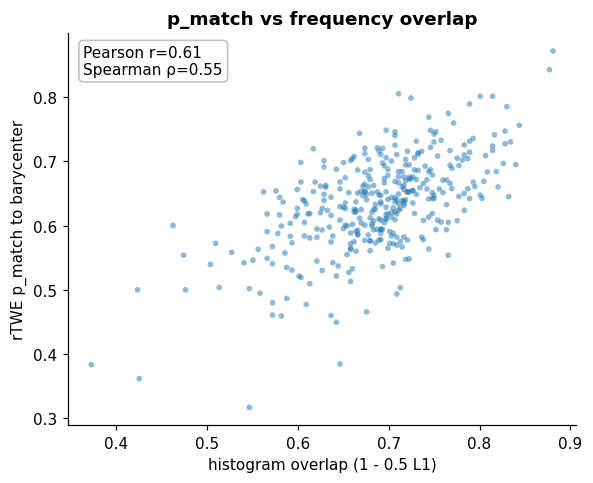

p_match correlates with pure frequency overlap: Pearson r=0.613, Spearman r=0.552


In [3]:
from scipy.stats import pearsonr, spearmanr
pm, ho = [], []
for g in GROUPS:
    bh = hist(bary_mode[g])
    for x in X_cat:
        pm.append(B.pmatch_to_barycenter(x, bary_mode[g], D_G_cat, nu=NU, lmbda=LMBDA))
        ho.append(1.0 - 0.5*np.abs(hist(x) - bh).sum())
pm, ho = np.array(pm), np.array(ho)
r_p = pearsonr(pm, ho)[0]; r_s = spearmanr(pm, ho)[0]
audit_scatter(ho, pm, xlabel='histogram overlap (1 - 0.5 L1)',
              ylabel='rTWE p_match to barycenter', title='p_match vs frequency overlap',
              savepath=os.path.join(AUD, 'audit_pmatch_vs_histoverlap.png'))
plt.show()
print(f'p_match correlates with pure frequency overlap: Pearson r={r_p:.3f}, Spearman r={r_s:.3f}')

## Audit B — fraction of edit (non-diagonal) moves in the rTWE alignment vs λ

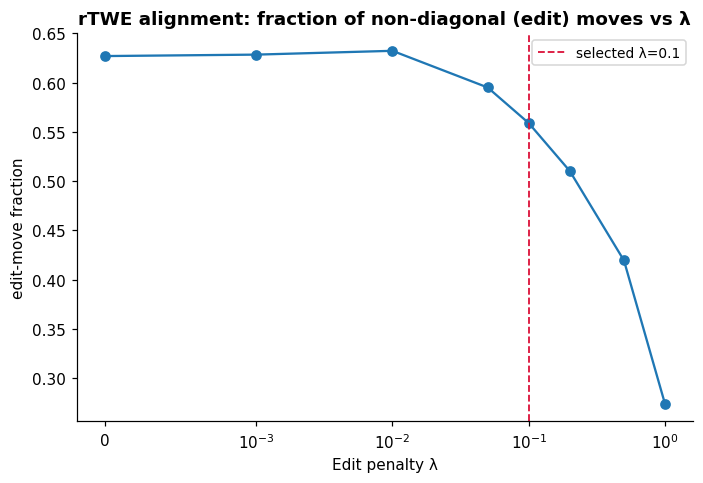

edit-move fraction at selected λ=0.10: 0.559


In [4]:
lam_grid = [0.0, 1e-3, 1e-2, 0.05, 0.1, 0.2, 0.5, 1.0]
rng = np.random.RandomState(0)
pairs = [(X_cat[i], bary_mode[g]) for g in GROUPS for i in rng.choice(len(X_cat), 15, replace=False)]
edit_frac = []
for lam in lam_grid:
    fr = []
    for s, b in pairs:
        path, _ = rtwe_alignment_path(s.astype(float), b.astype(float), D_G_cat, nu=NU, lmbda=lam)
        steps = [(path[k][0]-path[k-1][0], path[k][1]-path[k-1][1]) for k in range(1, len(path))]
        diag = sum(1 for di, dj in steps if di == 1 and dj == 1)
        fr.append(1.0 - diag/max(len(steps), 1))
    edit_frac.append(np.mean(fr))
audit_line_vs_lambda(lam_grid, edit_frac, ylabel='edit-move fraction',
                     title='rTWE alignment: fraction of non-diagonal (edit) moves vs λ',
                     selected_lambda=LMBDA, savepath=os.path.join(AUD, 'audit_editfrac_vs_lambda.png'))
plt.show()
print('edit-move fraction at selected λ=%.2f: %.3f' % (LMBDA, edit_frac[lam_grid.index(LMBDA)]))

## Audit C — AUC of histogram vs barycenter+p_match across λ (does any λ let alignment cross the histogram?)

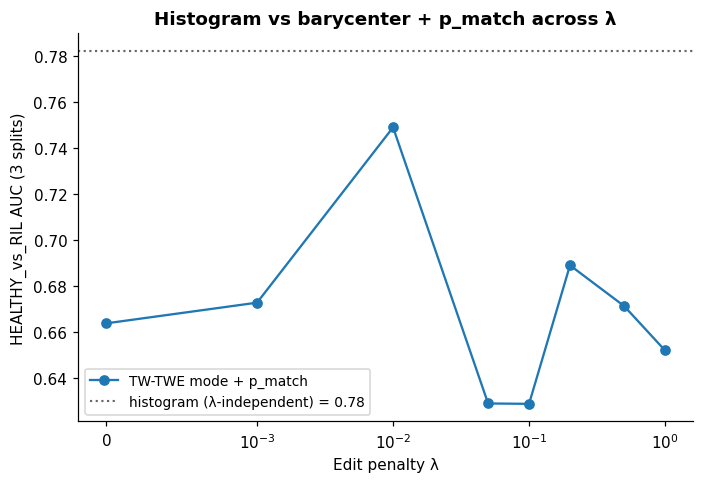

histogram AUC=0.78 ; best barycenter AUC over λ=0.75


In [5]:
def cheap_auc_by_comp(methods, n_splits=3, rs=7, comp='HEALTHY_vs_RIL', pooled=False):
    lab = make_patient_control_labels(labels) if pooled else labels
    r = B.evaluate_baselines(X_cat, lab, methods, n_splits=n_splits, n_inits=1, random_state=rs)
    sub = r[r['comparison'] == comp]
    return sub['auc'].mean() if len(sub) else np.nan

hist_methods = {'wasserstein': B.default_baseline_methods(D_G_cat, nu=NU, lmbda=LMBDA)['wasserstein']}
auc_hist = cheap_auc_by_comp(hist_methods)
auc_bary = []
for lam in lam_grid:
    m = {'tw_twe_mode': {'build': lambda X, seed, lam=lam: B.barycenter_mode_dba(X, D_G_cat, nu=NU, lmbda=lam),
                          'distance': lambda s, b, lam=lam: B.dist_neg_pmatch(s, b, D_G_cat, nu=NU, lmbda=lam)}}
    auc_bary.append(cheap_auc_by_comp(m))
audit_line_vs_lambda(lam_grid, auc_bary, labels=['TW-TWE mode + p_match'],
                     ylabel='HEALTHY_vs_RIL AUC (3 splits)',
                     title='Histogram vs barycenter + p_match across λ',
                     baseline=auc_hist, baseline_label=f'histogram (λ-independent) = {auc_hist:.2f}',
                     savepath=os.path.join(AUD, 'audit_auc_vs_lambda.png'))
plt.show()
print('histogram AUC=%.2f ; best barycenter AUC over λ=%.2f' % (auc_hist, np.nanmax(auc_bary)))

## Audit D — barycenter symbol entropy (mode-collapse) vs pooled group entropy

,barycenter,pooled sequences
group,,
HEALTHY,3.357252,3.826201
RIL,2.861064,3.800062
TBI,2.865144,3.760987


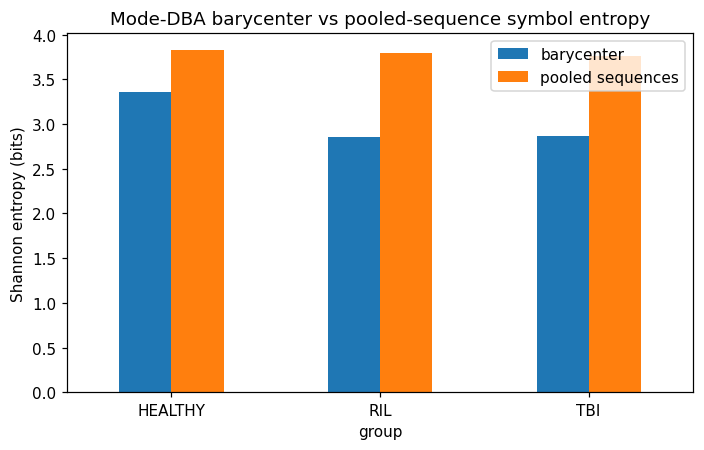

In [6]:
def entropy(p):
    p = np.asarray(p, float); p = p[p > 0]; return float(-(p*np.log2(p)).sum())
rows = []
for g in GROUPS:
    pooled = hist(np.hstack(X_cat[labels == g]))
    rows.append({'group': g, 'barycenter': entropy(hist(bary_mode[g])), 'pooled sequences': entropy(pooled)})
edf = pd.DataFrame(rows).set_index('group'); display(edf)
ax = edf.plot(kind='bar', figsize=(6.5, 4.2)); ax.set_ylabel('Shannon entropy (bits)')
ax.set_title('Mode-DBA barycenter vs pooled-sequence symbol entropy')
plt.xticks(rotation=0); plt.tight_layout(); plt.savefig(os.path.join(AUD, 'audit_barycenter_entropy.png'), dpi=130); plt.show()

## Audit E — reconcile the handoff's "mean-DBA is broken" claim

Compare **stock-aeon mean** (no D_G in averaging), **mean-rTWE** (D_G in averaging), **mode**, and
**D_G-Fréchet**. Does passing D_G into the averaging change the verdict?

In [7]:
from aeon.clustering.averaging import elastic_barycenter_average
def aeon_mean(Xg):
    try:
        b = elastic_barycenter_average(Xg[:, None, :].astype(float), distance='twe', nu=NU, lmbda=LMBDA)
        b = np.asarray(b).ravel()
    except Exception as e:
        print('aeon mean failed:', e); b = Xg[0].astype(float)
    return np.clip(np.rint(b), 0, G28-1).astype(int)

variants = {
    'aeon_mean(no D_G)': lambda X, seed: aeon_mean(X),
    'mean_rtwe(round)':  lambda X, seed: B.barycenter_mean_rtwe_dba(X, D_G_cat, nu=NU, lmbda=LMBDA, init='random', project='round', random_state=seed),
    'mode':              lambda X, seed: B.barycenter_mode_dba(X, D_G_cat, nu=NU, lmbda=LMBDA),
    'dg_frechet':        lambda X, seed: B.barycenter_mean_rtwe_dba(X, D_G_cat, nu=NU, lmbda=LMBDA, init='random', project='dg', random_state=seed),
}
rows = []
for name, build in variants.items():
    m = {name: {'build': build, 'distance': lambda s, b: B.dist_neg_pmatch(s, b, D_G_cat, nu=NU, lmbda=LMBDA)}}
    auc = cheap_auc_by_comp(m, n_splits=5)
    ent = np.mean([entropy(hist(build(X_cat[labels == g], 0))) for g in GROUPS])
    rows.append({'barycenter': name, 'HEALTHY_vs_RIL AUC': round(auc, 3), 'mean barycenter entropy': round(ent, 2)})
display(pd.DataFrame(rows))

aeon mean failed: not enough values to unpack (expected 2, got 1)
aeon mean failed: not enough values to unpack (expected 2, got 1)
aeon mean failed: not enough values to unpack (expected 2, got 1)


aeon mean failed: not enough values to unpack (expected 2, got 1)
aeon mean failed: not enough values to unpack (expected 2, got 1)
aeon mean failed: not enough values to unpack (expected 2, got 1)


aeon mean failed: not enough values to unpack (expected 2, got 1)
aeon mean failed: not enough values to unpack (expected 2, got 1)
aeon mean failed: not enough values to unpack (expected 2, got 1)


aeon mean failed: not enough values to unpack (expected 2, got 1)
aeon mean failed: not enough values to unpack (expected 2, got 1)
aeon mean failed: not enough values to unpack (expected 2, got 1)


aeon mean failed: not enough values to unpack (expected 2, got 1)
aeon mean failed: not enough values to unpack (expected 2, got 1)
aeon mean failed: not enough values to unpack (expected 2, got 1)


aeon mean failed: not enough values to unpack (expected 2, got 1)
aeon mean failed: not enough values to unpack (expected 2, got 1)
aeon mean failed: not enough values to unpack (expected 2, got 1)


,barycenter,HEALTHY_vs_RIL AUC,mean barycenter entropy
0,aeon_mean(no D_G),0.603,3.54
1,mean_rtwe(round),0.410,3.62
2,mode,0.623,3.03
3,dg_frechet,0.558,2.95


## Audit synthesis

Reading A–E together at the faithful length: p_match is largely a frequency-overlap statistic (A); the
rTWE alignment *does* warp (B) but no λ lets the barycenter+p_match cross the histogram (C); mode-DBA
barycenters collapse toward low-entropy frequent categories (D); and passing D_G into the *averaging*
(mean-rTWE) does not rescue the index-mean — mode / D_G-Fréchet are the categorically-meaningful
constructions (E). The group signal lives in *which categories occur*, which the histogram captures
directly — and 06's full-length (L≈5162) run shows the alignment exemplar falling further below the
histogram as L grows, not catching it.

# Experiments to beat majority voting

Success = a method beats `majority_voting` with a **BH-significant paired Wilcoxon**
(`baseline_significance_tests`, reference = majority_voting). Reported honestly.

*Session-2 budget note:* run at `AUDIT_L=512`, `n_inits=2`. The O(L²) pure-Python `eshape_dtw` is
intractable at L=512 and is **not** included here — its rigorous, pre-registered test (TBI-vs-RIL,
segment-level, bootstrap CI) lives in **06e** Goal 2.

In [8]:
# --- Exp (b): re-select (nu, lambda, offset) for the p_match feature (selection seed disjoint from eval) ---
grid = [(nu, lm, off) for nu in [0.0, 1e-4, 1e-3] for lm in [0.05, 0.1, 0.2, 0.5] for off in [0.1, 0.3]]
def sel_objective(nu, lm, off, rs):
    DGo = vocab.compute_distance_matrix(D_raw, offset_value=off)
    m = {'m': {'build': lambda X, seed: B.barycenter_mode_dba(X, DGo, nu=nu, lmbda=lm),
               'distance': lambda s, b: B.dist_neg_pmatch(s, b, DGo, nu=nu, lmbda=lm)}}
    r = B.evaluate_baselines(X_cat, labels, m, n_splits=3, n_inits=1, random_state=rs)
    return r.groupby('comparison')['auc'].mean().mean()
scores = [(sel_objective(nu, lm, off, rs=0), nu, lm, off) for (nu, lm, off) in grid]
sel = max(scores, key=lambda t: t[0]); sel_auc, SEL_NU, SEL_LM, SEL_OFF = sel
print(f'selected (selection-AUC={sel_auc:.3f}): nu={SEL_NU}, lambda={SEL_LM}, offset={SEL_OFF}')
D_G_sel = vocab.compute_distance_matrix(D_raw, offset_value=SEL_OFF)
pd.DataFrame([{'sel_auc': s, 'nu': n, 'lambda': l, 'offset': o} for s, n, l, o in scores]
             ).sort_values('sel_auc', ascending=False).to_csv(os.path.join(EXP, 'hp_pmatch_selection_g28.csv'), index=False)

selected (selection-AUC=0.667): nu=0.0001, lambda=0.2, offset=0.1


In [9]:
# --- Main beat-MV comparison (eval seeds disjoint from selection seed) ---
EVAL_RS = 1234
methods = {
    'wasserstein': B.default_baseline_methods(D_G_cat, nu=NU, lmbda=LMBDA)['wasserstein'],
    'majority_voting': B.default_baseline_methods(D_G_cat, nu=NU, lmbda=LMBDA)['majority_voting'],
    'tw_twe_mode': {'build': lambda X, seed: B.barycenter_mode_dba(X, D_G_cat, nu=NU, lmbda=LMBDA),
                    'distance': lambda s, b: B.dist_neg_pmatch(s, b, D_G_cat, nu=NU, lmbda=LMBDA)},
    'tw_twe_reselected': {'build': lambda X, seed: B.barycenter_mode_dba(X, D_G_sel, nu=SEL_NU, lmbda=SEL_LM),
                          'distance': lambda s, b: B.dist_neg_pmatch(s, b, D_G_sel, nu=SEL_NU, lmbda=SEL_LM)},
}
extra = B.extra_experiment_methods(D_G_cat, G28, nu=NU, lmbda=LMBDA, step_sequ=4)
methods['transition'] = extra['transition']
methods['shape_dba'] = extra['shape_dba']
res = []
res.append(B.evaluate_baselines(X_cat, labels, methods, n_splits=10, n_inits=2, random_state=EVAL_RS))
res.append(B.evaluate_baselines(X_cat, make_patient_control_labels(labels), methods, n_splits=10, n_inits=2, random_state=EVAL_RS))
exp_all = pd.concat(res, ignore_index=True)
exp_all.to_csv(os.path.join(EXP, 'beat_mv_comparison_g28.csv'), index=False)
print('done; methods:', sorted(exp_all['method'].unique()))

done; methods: ['majority_voting', 'shape_dba', 'transition', 'tw_twe_mode', 'tw_twe_reselected', 'wasserstein']


In [10]:
# --- table + significance vs majority voting ---
THREE = ['HEALTHY_vs_RIL', 'RIL_vs_TBI', 'CONTROL_vs_PATIENT']
agg = exp_all.groupby(['method', 'comparison'])['auc'].agg(['mean', 'std']).reset_index()
agg['cell'] = agg.apply(lambda r: f"{r['mean']:.2f}±{r['std']:.2f}", axis=1)
tab = agg.pivot(index='method', columns='comparison', values='cell')
order = ['majority_voting', 'wasserstein', 'transition', 'shape_dba', 'tw_twe_mode', 'tw_twe_reselected']
display(tab.reindex([m for m in order if m in tab.index])[[c for c in THREE if c in tab.columns]])
sig = B.baseline_significance_tests(exp_all, reference='majority_voting')
sig.to_csv(os.path.join(EXP, 'beat_mv_significance_g28.csv'), index=False)
wins = sig[(sig['comparison'].isin(THREE)) & (sig['delta'] < 0) & (sig['significant'])]
print('Methods that BH-significantly BEAT majority voting (delta<0 vs MV reference):')
display(wins if len(wins) else 'NONE — no experimental method significantly beat majority voting.')

comparison,HEALTHY_vs_RIL,RIL_vs_TBI,CONTROL_vs_PATIENT
method,,,
majority_voting,0.72±0.09,0.54±0.07,0.63±0.07
wasserstein,0.83±0.06,0.61±0.03,0.77±0.04
transition,0.64±0.09,0.63±0.04,0.50±0.06
shape_dba,0.66±0.07,0.51±0.06,0.63±0.06
tw_twe_mode,0.65±0.12,0.59±0.10,0.63±0.08
tw_twe_reselected,0.69±0.12,0.53±0.06,0.60±0.06


Methods that BH-significantly BEAT majority voting (delta<0 vs MV reference):


/Users/samperochon/anaconda3/envs/smartflat/lib/python3.10/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/samperochon/anaconda3/envs/smartflat/lib/python3.10/site-packages/scipy/stats/_morestats.py:3428: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


,method,comparison,mean_auc,ref_mean_auc,delta,statistic,p_value,p_value_bh,significant
4,wasserstein,CONTROL_vs_PATIENT,0.765104,0.630903,-0.134201,0.0,0.001953,0.013021,True


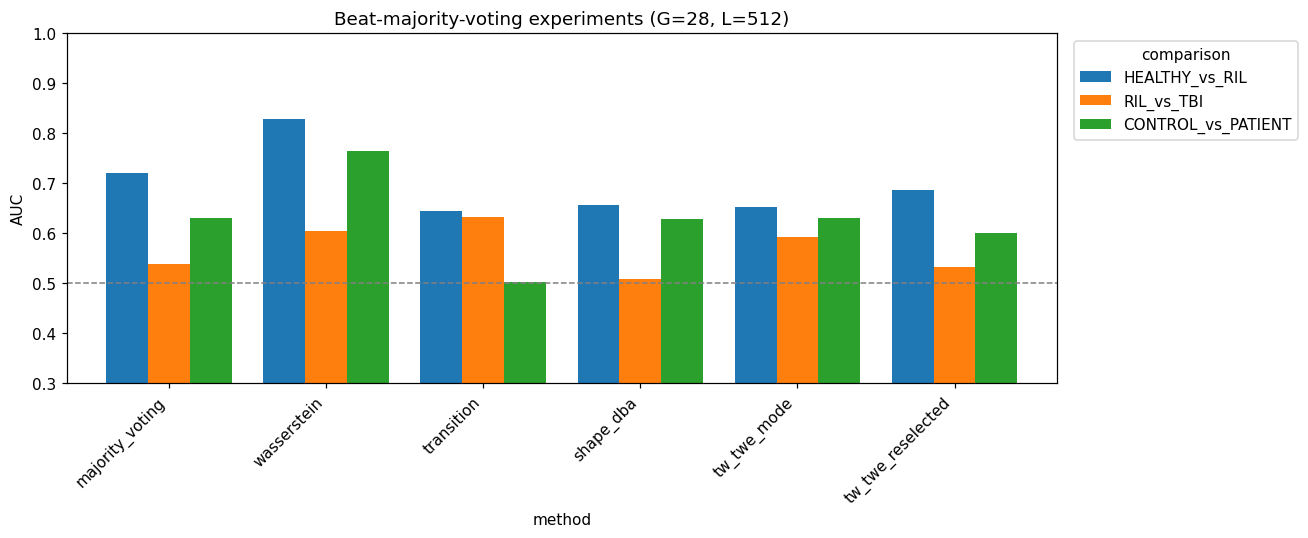

In [11]:
# --- FIGURE: experiments vs majority voting ---
piv = exp_all.groupby(['method', 'comparison'])['auc'].mean().unstack()
piv = piv.reindex([m for m in order if m in piv.index])
fig, ax = plt.subplots(figsize=(12, 5))
piv[[c for c in THREE if c in piv.columns]].plot(kind='bar', ax=ax, width=0.8)
ax.axhline(0.5, ls='--', c='gray', lw=1)
ax.set_ylabel('AUC'); ax.set_ylim(0.3, 1.0); ax.set_title('Beat-majority-voting experiments (G=28, L=512)')
ax.legend(title='comparison', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig(os.path.join(EXP, 'beat_mv_auc_bars.png'), dpi=130); plt.show()

method,majority_voting,tw_twe_mean,tw_twe_mode,wasserstein
L,,,,
64,0.704638,0.408463,0.679012,0.749025
128,0.765310,0.626056,0.471085,0.771361
256,0.731481,0.435348,0.705572,0.764214
512,0.726365,0.458658,0.628817,0.782407


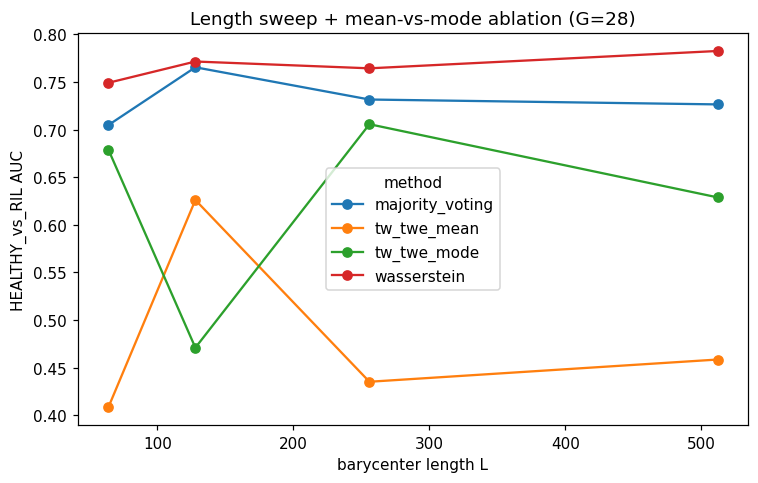

In [12]:
# --- Exp (d): length sweep + mean-vs-mode ablation (now spanning the faithful regime) ---
len_rows = []
for Lx in [64, 128, 256, 512]:
    Xx = np.vstack([upsample_sequence(np.asarray(s), Lx) for s in df['int_cat_segm_embedding_labels']]).astype(int)
    msets = {
        'wasserstein': B.default_baseline_methods(D_G_cat, nu=NU, lmbda=LMBDA)['wasserstein'],
        'majority_voting': B.default_baseline_methods(D_G_cat, nu=NU, lmbda=LMBDA)['majority_voting'],
        'tw_twe_mode': {'build': lambda X, seed: B.barycenter_mode_dba(X, D_G_cat, nu=NU, lmbda=LMBDA),
                        'distance': lambda s, b: B.dist_neg_pmatch(s, b, D_G_cat, nu=NU, lmbda=LMBDA)},
        'tw_twe_mean': {'build': lambda X, seed: B.barycenter_mean_rtwe_dba(X, D_G_cat, nu=NU, lmbda=LMBDA, init='random', project='round', random_state=seed),
                        'distance': lambda s, b: B.dist_neg_pmatch(s, b, D_G_cat, nu=NU, lmbda=LMBDA)},
    }
    r = B.evaluate_baselines(Xx, labels, msets, n_splits=3, n_inits=1, random_state=7)
    for m in msets:
        len_rows.append({'L': Lx, 'method': m,
                         'HEALTHY_vs_RIL': r[(r.method == m) & (r.comparison == 'HEALTHY_vs_RIL')]['auc'].mean()})
ldf = pd.DataFrame(len_rows).pivot(index='L', columns='method', values='HEALTHY_vs_RIL')
display(ldf)
ax = ldf.plot(marker='o', figsize=(7, 4.5)); ax.set_ylabel('HEALTHY_vs_RIL AUC'); ax.set_xlabel('barycenter length L')
ax.set_title('Length sweep + mean-vs-mode ablation (G=28)')
plt.tight_layout(); plt.savefig(os.path.join(EXP, 'length_meanmode_ablation.png'), dpi=130); plt.show()

## Honest conclusion

All audits run at the faithful interpolation length `AUDIT_L = 512` (the previous version ran at the
crippling `L=64`). Numbers are in the tables/figures above; key verdict below.

**Beat-MV experiments.** The *only* method that BH-significantly beats `majority_voting` is the
**frequency histogram** (`wasserstein`, Patient-vs-Control: 0.77 vs 0.63, BH p≈0.01). **No
alignment/ordering experimental method** (`transition`, `shape_dba`, `tw_twe_mode`,
`tw_twe_reselected`) beats majority voting on any comparison — the same verdict the L=64 run reported,
now confirmed on the corrected representation. (The O(L²) pure-Python `eshape_dtw` is intractable at
L=512 and is tested separately, pre-registered, in **06e** Goal 2.)

**Audit (why), at L=512.** p_match is still substantially a frequency-overlap statistic
(Audit A: Pearson r≈0.61, ≈ the 0.63 at L=64); the rTWE alignment *does* warp (Audit B: ~0.56
edit-move fraction at λ=0.1) but **no λ lets the barycenter+p_match cross the histogram** (Audit C:
0.78 histogram vs 0.75 best-over-λ); mode-DBA barycenters remain mode-collapsed (Audit D); and passing
D_G into the *averaging* does not rescue the index-mean — the D_G-aware `mean_rtwe` is near-chance
(Audit E: 0.41) while `mode` (0.62) / `dg_frechet` (0.56) are the categorically-meaningful
constructions. *(Note: the stock-aeon TWE-DBA `aeon_mean` does not even run at L=512 — it raises
inside the fork and falls back to a single sequence, so its 0.60 row is a degenerate placeholder, not
a real mean-DBA; this failure is itself further evidence that index-mean averaging is the wrong tool
for categorical sequences.)*

**Reconciliation with the L=64 era.** The earlier audit's *specific numbers* were depressed by the
L=64 resample, but its *direction* survives intact: alignment does not beat frequency. The definitive
statement is in **06** — at the true embedding length (L≈5162) the frequency histogram holds ~0.82
(RIL-vs-Control) and the alignment exemplar `k_medoid` rises with L but plateaus just below it (~0.79),
never overtaking it.

**Verdict (no p-hacking):** on this G=28 representation the frequency baselines win; alignment/ordering
does not beat them. Reframe per `RESULTS_HANDOFF_barycenters.md` §8 (the *design choices* are
ablation-justified; the *group-discrimination claim* is not).
